In [20]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms


In [15]:
lr_path = "../data/processed/DIV2K/DIV2K_train_LR_x4/0052.png"
hr_path = "../data/raw/DIV2K/DIV2K_train_HR/0052.png"
lr = Image.open(lr_path)
hr = Image.open(hr_path)
lr_up = lr.resize(hr.size, resample=Image.BICUBIC)

In [19]:
print(f"HR size : {hr.size} LR size : {lr_up.size}")

HR size : (2040, 1356) LR size : (2040, 1356)


(np.float64(-0.5), np.float64(2039.5), np.float64(1355.5), np.float64(-0.5))

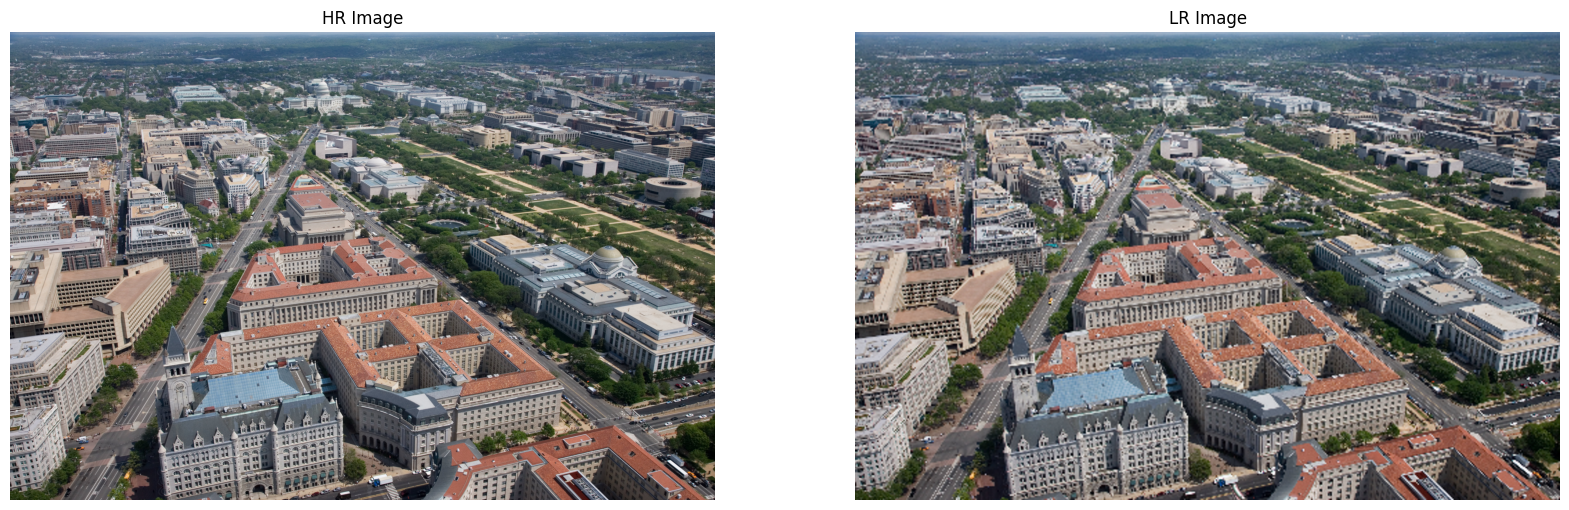

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 20))

axes[0].imshow(hr)
axes[0].set_title('HR Image')
axes[0].axis('off')

axes[1].imshow(lr_up)
axes[1].set_title('LR Image')
axes[1].axis('off')

In [32]:
conv1 = nn.Conv2d(3, 64, kernel_size=9, padding=4)
relu1 = nn.ReLU(inplace=True)
to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

In [35]:
lr_tensor = to_tensor(lr_up).unsqueeze(0)
print(f"LR tensor shape : {lr_tensor.shape}")
lr_tensor_conv1 = relu1(conv1(lr_tensor))
lr_tensor_conv1 = lr_tensor_conv1.squeeze(0)
print(f"LR after conv1 and relu1 tensor shape : {lr_tensor_conv1.shape}")

LR tensor shape : torch.Size([1, 3, 1356, 2040])
LR after conv1 and relu1 tensor shape : torch.Size([64, 1356, 2040])


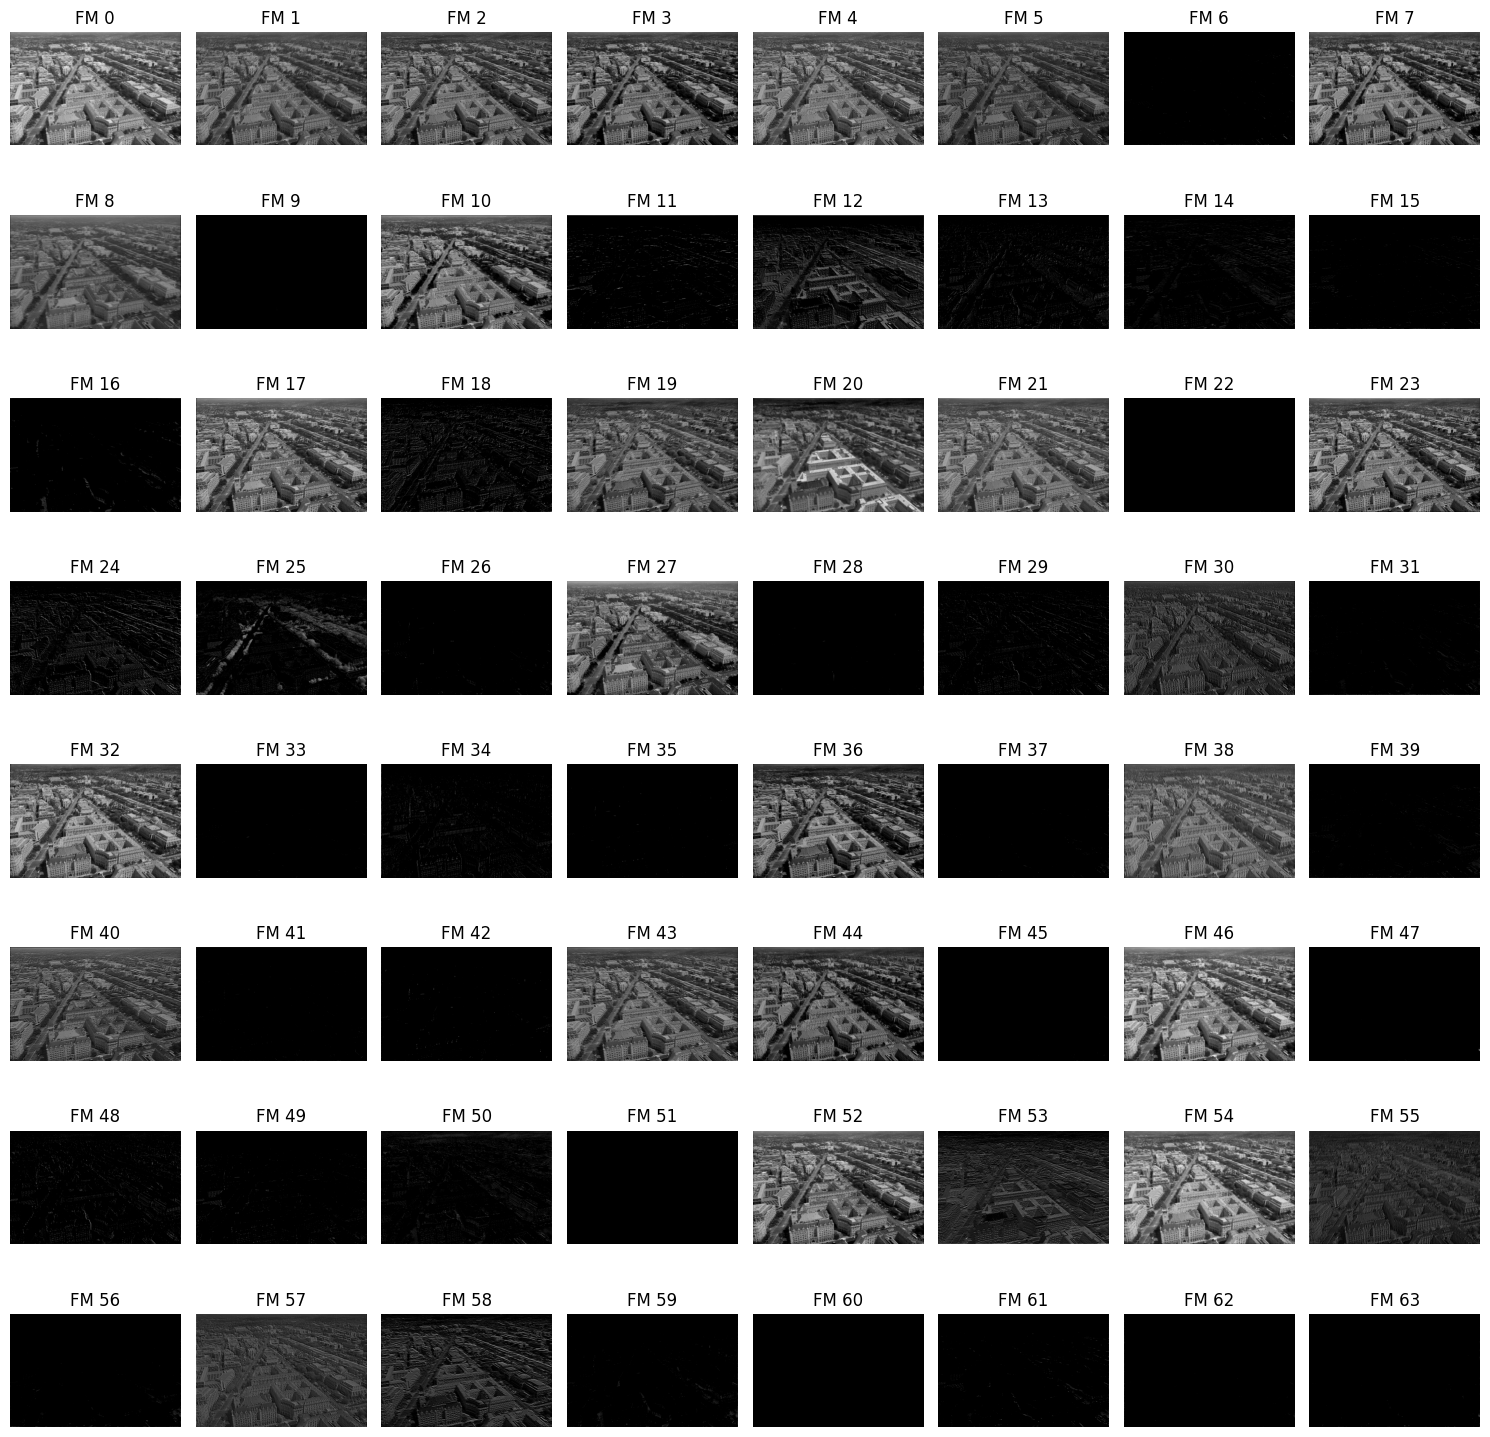

In [36]:
fig, axes = plt.subplots(8, 8, figsize=(15, 15))
for i in range(64):
    ax = axes[i // 8, i % 8]
    ax.imshow(lr_tensor_conv1[i].detach().cpu().numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(f"FM {i}")

plt.tight_layout()
plt.show()